# Universal approximation with different activation functions
### A visual comparison built on `activation_networks.py`

This companion notebook uses the `activation_networks` module to *produce* one-hidden-layer
networks for several activation functions and compare them on the same targets. The theme,
following Kupka–Alijani–Števuliáková, is:

> a **standard** activation (tanh, sigmoid, ReLU, …) needs **many** neurons, while the paper's
> **constructed** activation $\kappa$ reaches the same accuracy with a **handful** — 2 neurons in
> one dimension (Corollary 6.1), $2n$ for the ridge class (Theorem 4.2).

We look at three things:
1. what the activation functions look like,
2. how well each fits a target for a fixed neuron budget,
3. the **error-vs-neurons** convergence curves, with $\kappa$'s constructive 2-neuron result marked.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import activation_networks as an

plt.rcParams["figure.dpi"] = 120
rng = np.random.default_rng(0)

# the target we approximate throughout
target = lambda x: np.sin(3 * x) * np.exp(-0.3 * x)
xs = np.linspace(-1, 1, 600)
yt = target(xs)

STD = ["tanh", "sigmoid", "relu", "sin", "gelu"]     # standard activations
kappa = an.make_kappa(count=40)                       # the paper's activation
print("activations:", STD + ["kappa"])

activations: ['tanh', 'sigmoid', 'relu', 'sin', 'gelu', 'kappa']


## 1. The activation functions

The standard activations are simple closed forms. $\kappa$ is the specially *constructed*
strictly-increasing, smooth, sigmoidal function that encodes a dense family of polynomials — its
tiny "encoding bumps" near the origin are what make 2-neuron approximation possible.

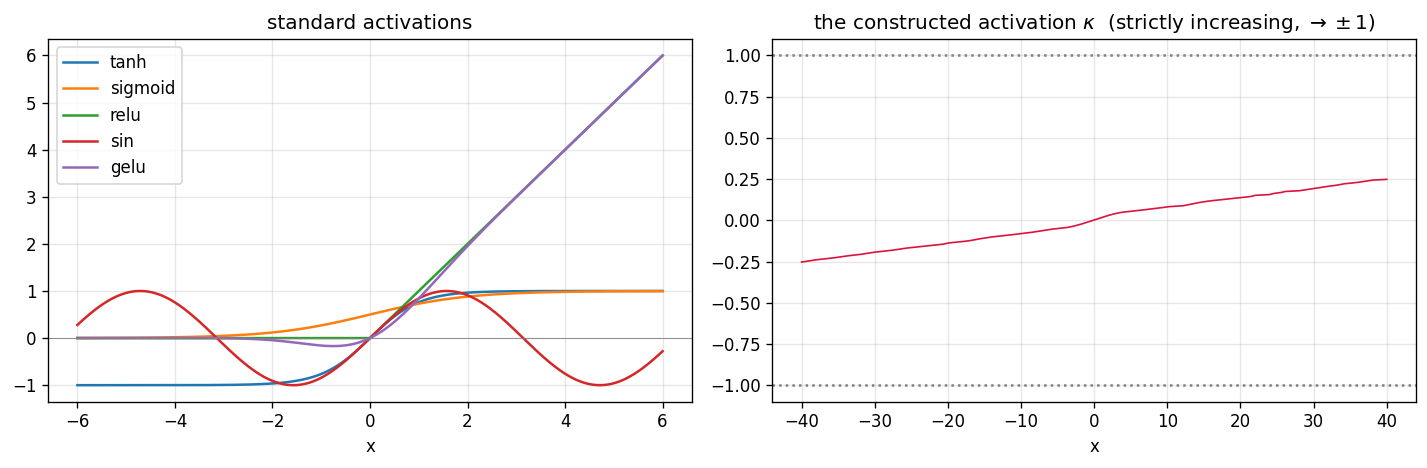

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
grid = np.linspace(-6, 6, 800)
for name in STD:
    ax[0].plot(grid, an.get_activation(name)(grid), label=name)
ax[0].set_title("standard activations"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[0].set_xlabel("x"); ax[0].axhline(0, color="gray", lw=.5)

kgrid = np.linspace(-40, 40, 40000)
ax[1].plot(kgrid, kappa(kgrid), color="crimson", lw=1)
ax[1].set_title(r"the constructed activation $\kappa$  (strictly increasing, $\to\pm1$)")
ax[1].set_xlabel("x"); ax[1].axhline(1, color="gray", ls=":"); ax[1].axhline(-1, color="gray", ls=":")
ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 2. Fitting the target with a fixed neuron budget

Each standard activation gets a one-hidden-layer network with the same number of neurons, fit by
least squares (`build_one_hidden_layer`). $\kappa$ uses its **constructive 2-neuron** network
(`kappa_corollary_61`). Watch how the standard activations with a *small* budget struggle where
$\kappa$ — with just 2 neurons — is essentially exact.

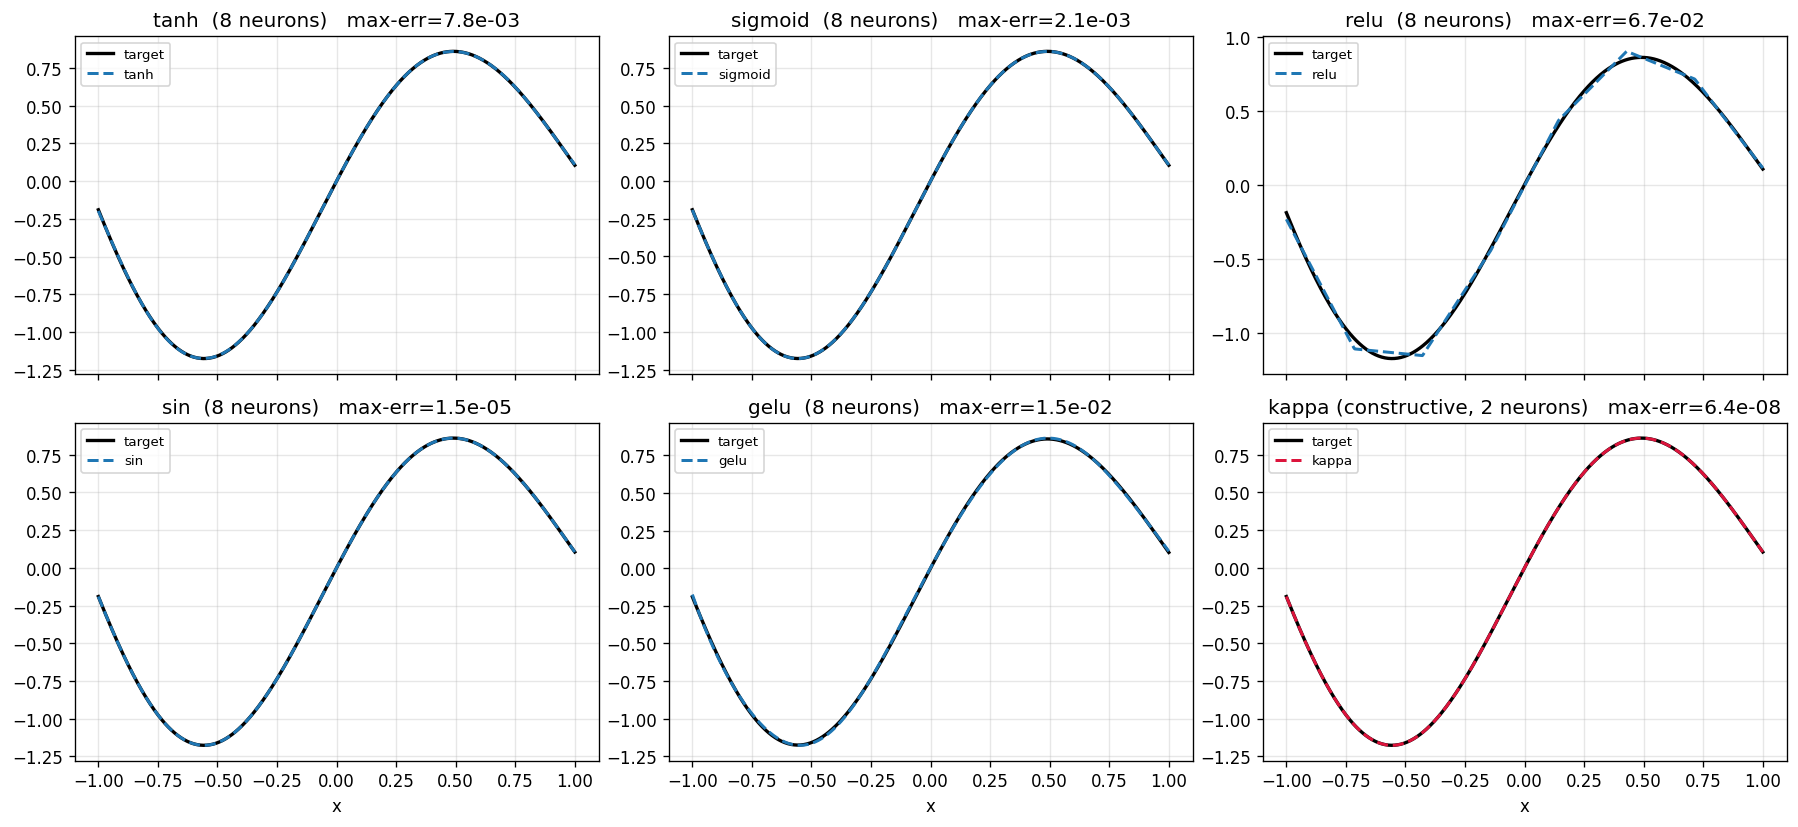

In [3]:
budget = 8
fig, ax = plt.subplots(2, 3, figsize=(15, 7), sharex=True)
ax = ax.ravel()

# standard activations at the fixed budget
for a, name in zip(ax, STD):
    net = an.build_one_hidden_layer(name, target, budget, xs)
    e = np.max(np.abs(net(xs) - yt))
    a.plot(xs, yt, "k", lw=2, label="target")
    a.plot(xs, net(xs), "--", lw=1.8, label=f"{name}")
    a.set_title(f"{name}  ({budget} neurons)   max-err={e:.1e}")
    a.legend(fontsize=8); a.grid(alpha=.3)

# kappa: constructive 2 neurons
predict, info = an.kappa_corollary_61(target, degree=12)
ax[5].plot(xs, yt, "k", lw=2, label="target")
ax[5].plot(xs, predict(xs), "--", color="crimson", lw=1.8, label="kappa")
ax[5].set_title(f"kappa (constructive, 2 neurons)   max-err={info['max_error']:.1e}")
ax[5].legend(fontsize=8); ax[5].grid(alpha=.3)
for a in ax[3:]: a.set_xlabel("x")
plt.tight_layout(); plt.show()

## 3. Error vs. number of neurons

The decisive picture. For each standard activation we grow the hidden layer and record the max
error; for $\kappa$ we mark the constructive **2-neuron** error as a horizontal line. Standard
activations need one to two *orders of magnitude* more neurons to match it.

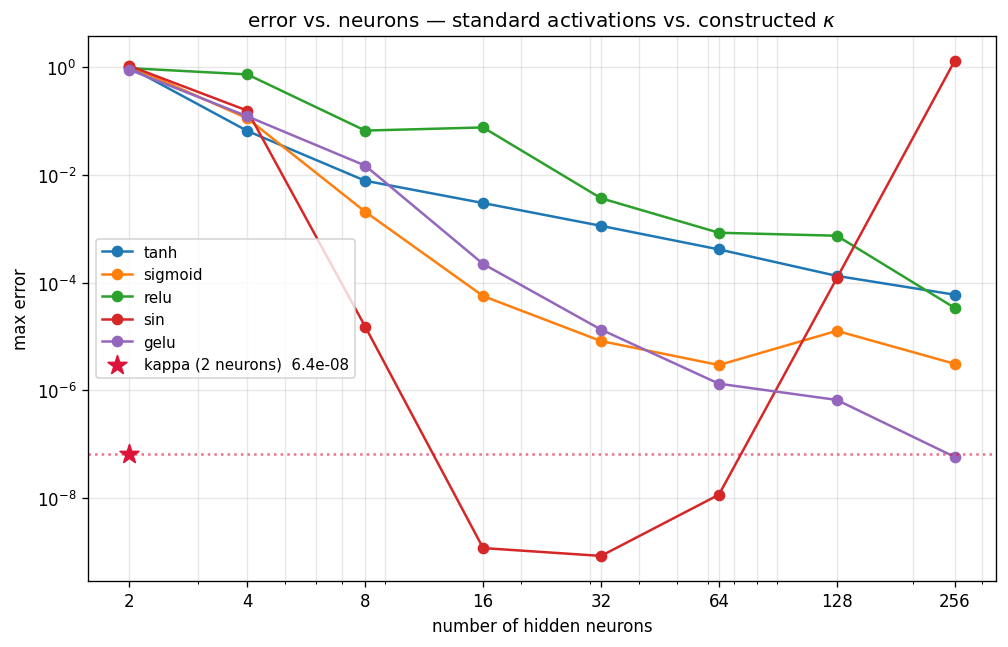

In [4]:
budgets = [2, 4, 8, 16, 32, 64, 128, 256]
fig, ax = plt.subplots(figsize=(8.5, 5.5))
for name in STD:
    errs = []
    for m in budgets:
        net = an.build_one_hidden_layer(name, target, m, xs, seed=0)
        errs.append(np.max(np.abs(net(xs) - yt)))
    ax.loglog(budgets, errs, "o-", label=name)

# kappa constructive 2-neuron result
kap_err = an.kappa_corollary_61(target, degree=12)[1]["max_error"]
ax.scatter([2], [kap_err], s=140, marker="*", color="crimson", zorder=5,
           label=f"kappa (2 neurons)  {kap_err:.1e}")
ax.axhline(kap_err, color="crimson", ls=":", alpha=.6)

ax.set_xlabel("number of hidden neurons"); ax.set_ylabel("max error")
ax.set_title("error vs. neurons — standard activations vs. constructed $\kappa$")
ax.legend(fontsize=9); ax.grid(alpha=.3, which="both")
ax.set_xticks(budgets); ax.set_xticklabels(budgets)
plt.tight_layout(); plt.show()

## 4. The constructive $\kappa$ networks in higher dimension (Theorem 4.2)

For the ridge class $\mathcal M_n=\{\sum_i g_i(\bar a_i\!\cdot\!\bar x)\}$, $\kappa$ needs only $2n$
neurons in a single hidden layer. Here $d=2$, $n=2$ → **4 neurons**.

neurons = 4 (= 2n),  max-err = 2.88e-09


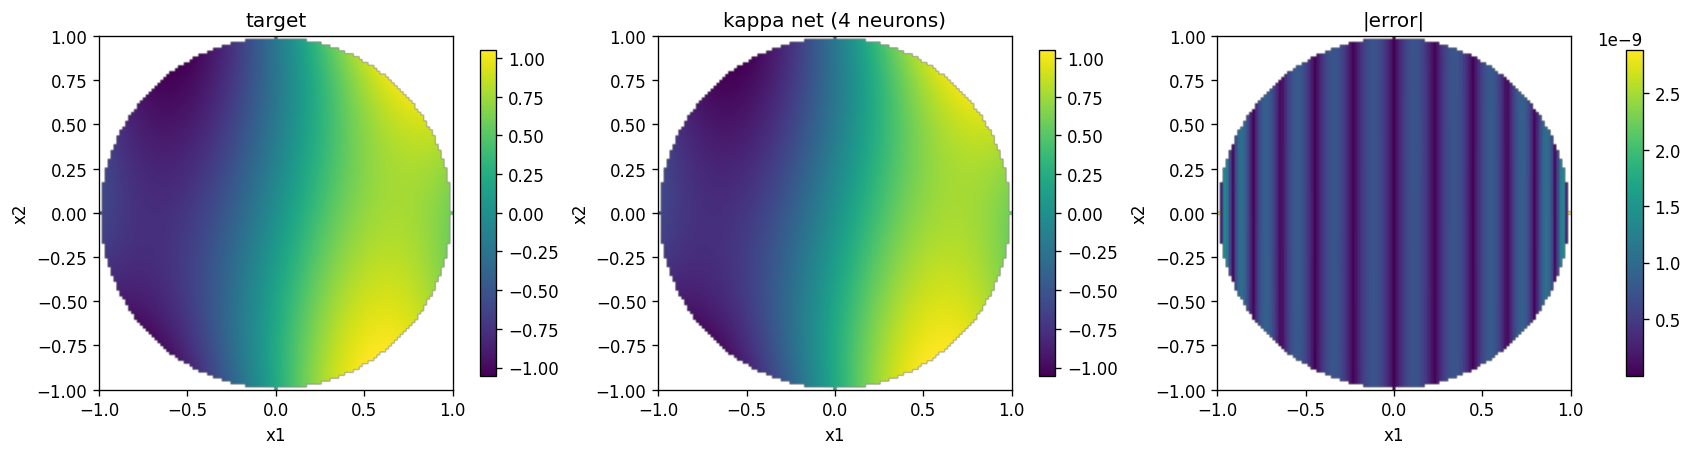

In [5]:
dirs = np.array([[1.0, 0.0], [1/np.sqrt(2), 1/np.sqrt(2)]])   # a_1, a_2
ridge = [lambda s: np.sin(2.2 * s), lambda s: 0.6 * (s**3 - s)]
predict, info = an.kappa_theorem_42(ridge, dirs, degree=12)

ax1 = np.linspace(-1, 1, 121); GX, GY = np.meshgrid(ax1, ax1)
P = np.column_stack([GX.ravel(), GY.ravel()]); inside = (P**2).sum(1) <= 1
Pb = P[inside]
f_true = sum(g(Pb @ a) for g, a in zip(ridge, dirs))
f_pred = predict(Pb)
print(f"neurons = {info['n_neurons']} (= 2n),  max-err = {info['max_error']:.2e}")

def disc(vals):
    img = np.full(GX.shape, np.nan); img.ravel()[inside] = vals; return img
fig, ax = plt.subplots(1, 3, figsize=(14, 4.2), constrained_layout=True)
for a, (im, ti) in zip(ax, [(f_true, "target"), (f_pred, "kappa net (4 neurons)"),
                            (np.abs(f_pred - f_true), "|error|")]):
    h = a.imshow(disc(im), origin="lower", extent=[-1, 1, -1, 1], cmap="viridis")
    a.set_title(ti); a.set_xlabel("x1"); a.set_ylabel("x2")
    fig.colorbar(h, ax=a, fraction=.046, pad=.04)
plt.show()

## Takeaway

`activation_networks.py` builds a one-hidden-layer network for **any** activation; swapping the
activation is a one-line change. The comparison makes the paper's message concrete: with a
*cleverly constructed* strictly-increasing activation $\kappa$, the network **structure** collapses
to the theoretical minimum (2 neurons in 1-D, $2n$ for ridge functions) while retaining the
universal approximation property — something standard activations achieve only with many more
neurons.
